# Chapter 1 — Markov chain Monte Carlo

*A walk-through companion to the thesis "Variance Reduction for Training Neural
Bayes Estimators".*

Bayesian inference treats an unknown parameter vector $\boldsymbol{\theta} \in
\Theta$ as a random quantity. Given a likelihood $p(\mathbf{y} \mid
\boldsymbol{\theta})$ for observed data $\mathbf{y}$ and a prior density
$p(\boldsymbol{\theta})$, Bayes' rule combines the two into the posterior

$$
\begin{align}
  p(\boldsymbol{\theta} \mid \mathbf{y})
  = \frac{p(\mathbf{y} \mid \boldsymbol{\theta})\,p(\boldsymbol{\theta})}
         {p(\mathbf{y})},
  \qquad
  p(\mathbf{y}) = \int_{\Theta}
  p(\mathbf{y} \mid \boldsymbol{\theta})\,p(\boldsymbol{\theta})
  \, \mathrm{d}\boldsymbol{\theta}.
  \tag{1}
\end{align}
$$

For inference one is most often interested in posterior summaries: the
posterior mean, variance, quantiles, or more generally a posterior expectation
$\mathbb{E}[g(\boldsymbol{\theta}) \mid \mathbf{y}] = \int
g(\boldsymbol{\theta})\, p(\boldsymbol{\theta} \mid \mathbf{y})\,
\mathrm{d}\boldsymbol{\theta}$ of some function $g$.

Two obstacles recur. First, the marginal likelihood $p(\mathbf{y})$ in $(1)$ is
typically intractable, so the posterior is known only up to a normalising
constant,

$$
\begin{align}
  p(\boldsymbol{\theta} \mid \mathbf{y}) \;\propto\;
  p(\mathbf{y} \mid \boldsymbol{\theta})\,p(\boldsymbol{\theta}).
  \tag{2}
\end{align}
$$

Second, even when $p(\mathbf{y})$ is available, $\boldsymbol{\theta}$ may be
high-dimensional, so posterior expectations are themselves expensive integrals.
Monte Carlo integration addresses both at once: given samples
$\boldsymbol{\theta}^{(1)}, \dots, \boldsymbol{\theta}^{(N)}$ drawn from the
posterior,

$$
\begin{align}
  \mathbb{E}[g(\boldsymbol{\theta}) \mid \mathbf{y}]
  \;\approx\; \frac{1}{N}\sum_{i=1}^{N} g(\boldsymbol{\theta}^{(i)}),
  \tag{3}
\end{align}
$$

with the approximation sharpening as $N$ grows. The difficulty is the sampling
step: the unnormalised posterior $(2)$ cannot, in general, be sampled directly.

**Markov chain Monte Carlo (MCMC)** resolves this by producing the draws in
$(3)$ not independently but as the successive states of a Markov chain
constructed to have the posterior as its limiting distribution. This notebook
walks through the two samplers used as exact per-dataset references throughout
the thesis — random-walk **Metropolis–Hastings** and the **Gibbs sampler** —
made concrete on the normal model

$$
\begin{align}
  (y_1, \dots, y_n \mid \mu, \sigma) \overset{\text{iid}}{\sim}
  \mathcal{N}(\mu, \sigma^2),
  \qquad
  \mu \sim \mathcal{N}(\mu_0, \sigma_0^2),
  \qquad
  \sigma \sim \mathcal{U}(0, A),
  \tag{4}
\end{align}
$$

with estimand $\boldsymbol{\theta} = (\mu, \sigma)$ and, in the experiments that
follow, $\mu_0 = 0$, $\sigma_0 = 1$, $A = 5$. The model is a controlled test
case rather than a genuine application: its posterior is available in closed
form up to a normalising constant, so an accurate reference can be computed for
every test dataset and an amortised neural estimator (Chapter 2) checked
against it. The chapter closes with a conceptual note on Hamiltonian Monte
Carlo and the cost argument that motivates amortisation.

In [1]:
import sys; sys.path.insert(0, "src")
import numpy as np, matplotlib.pyplot as plt
RUN_FULL = False          # flip to True to recompute the heavy results from scratch
rng = np.random.default_rng(0)

from nbe.simulators import simulate_normal, sample_prior_normal
from nbe.samplers import mh_normal
from nbe.plotting import est_vs_true, convergence_curves

# Prior / sampler settings, matching the thesis experiments
# (SRC/final/normal_cost_benchmark.py).
MU0, SIGMA0_PRIOR, SIGMA_HI = 0.0, 1.0, 5.0   # prior: mu ~ N(0,1), sigma ~ U(0,5)
N_OBS = 100                                   # observations per dataset
N_ITER, BURN_IN = 5000, 1000                  # MH chain length and burn-in
PROP_SCALE = 0.15                             # random-walk proposal std

print(f"settings: n_obs={N_OBS}, iters={N_ITER} (burn-in {BURN_IN}), "
      f"prop_scale={PROP_SCALE}")

settings: n_obs=100, iters=5000 (burn-in 1000), prop_scale=0.15


## 1. The Metropolis–Hastings algorithm

A Markov chain on $\Theta$ is specified by a transition kernel
$T(\boldsymbol{\theta}' \mid \boldsymbol{\theta})$, the density of moving to
$\boldsymbol{\theta}'$ from the current state $\boldsymbol{\theta}$. A
distribution $\pi$ is **stationary** for $T$ if it is left invariant by the
transition, $\int T(\boldsymbol{\theta}' \mid \boldsymbol{\theta})\,
\pi(\boldsymbol{\theta})\,\mathrm{d}\boldsymbol{\theta} =
\pi(\boldsymbol{\theta}')$. The design problem for MCMC is to construct a kernel
whose stationary distribution is the target posterior. A convenient sufficient
condition is **detailed balance**: $T$ satisfies detailed balance with respect
to $\pi$ if

$$
\begin{align}
  T(\boldsymbol{\theta}' \mid \boldsymbol{\theta})\,\pi(\boldsymbol{\theta})
  = T(\boldsymbol{\theta} \mid \boldsymbol{\theta}')\,\pi(\boldsymbol{\theta}')
  \qquad \text{for all } \boldsymbol{\theta}, \boldsymbol{\theta}' \in \Theta.
  \tag{5}
\end{align}
$$

Integrating both sides of $(5)$ over $\boldsymbol{\theta}$ and using that
$T(\,\cdot \mid \boldsymbol{\theta}')$ is a probability density gives
$\int T(\boldsymbol{\theta}' \mid \boldsymbol{\theta})\,\pi(\boldsymbol{\theta})
\,\mathrm{d}\boldsymbol{\theta} = \pi(\boldsymbol{\theta}')$, so detailed
balance implies stationarity. A chain that is reversible with respect to $\pi$
and **ergodic** (irreducible and aperiodic) converges to $\pi$ from any
starting state, and the sample average $(3)$ converges to the corresponding
expectation — even though successive draws are correlated.

**The algorithm.** Let us construct such a chain from an arbitrary proposal
mechanism. From the current state $\boldsymbol{\theta}$, draw a candidate
$\boldsymbol{\theta}'$ from a **proposal distribution**
$q(\boldsymbol{\theta}' \mid \boldsymbol{\theta})$, and accept it with
probability

$$
\begin{align}
  \alpha(\boldsymbol{\theta}, \boldsymbol{\theta}')
  = \min\!\left(1,\;
  \frac{p(\boldsymbol{\theta}' \mid \mathbf{y})\,
        q(\boldsymbol{\theta} \mid \boldsymbol{\theta}')}
       {p(\boldsymbol{\theta} \mid \mathbf{y})\,
        q(\boldsymbol{\theta}' \mid \boldsymbol{\theta})}\right);
  \tag{6}
\end{align}
$$

otherwise the chain remains at $\boldsymbol{\theta}$. The acceptance
probability $(6)$ depends on the posterior only through the ratio
$p(\boldsymbol{\theta}' \mid \mathbf{y}) / p(\boldsymbol{\theta} \mid
\mathbf{y})$, and by Bayes' rule $(1)$ the evidence $p(\mathbf{y})$ cancels
from this ratio,

$$
\begin{align}
  \frac{p(\boldsymbol{\theta}' \mid \mathbf{y})}
       {p(\boldsymbol{\theta} \mid \mathbf{y})}
  = \frac{p(\mathbf{y} \mid \boldsymbol{\theta}')\,p(\boldsymbol{\theta}')}
         {p(\mathbf{y} \mid \boldsymbol{\theta})\,p(\boldsymbol{\theta})},
  \tag{7}
\end{align}
$$

so the algorithm requires only the unnormalised posterior $(2)$. This is what
makes Metropolis–Hastings applicable to a generic intractable posterior. The
chain it produces satisfies detailed balance $(5)$ with respect to the
posterior; the verification is a direct substitution of $(6)$ into $(5)$.

**The normal model specifically.** For the model $(4)$ the data enter only
through the sufficient statistics $\bar{y} = \tfrac1n\sum_i y_i$ and
$S = \sum_i (y_i - \bar y)^2$, and the log-posterior is

$$
\begin{align}
  \log p(\mu, \sigma \mid \mathbf{y})
  = -n\log\sigma
    - \frac{1}{2\sigma^2}\big(S + n(\bar{y} - \mu)^2\big)
    - \frac{(\mu - \mu_0)^2}{2\sigma_0^2}
    + C,
  \tag{8}
\end{align}
$$

valid for $\sigma \in (0, A)$ and $-\infty$ otherwise, with $C$ the unknown
normalising constant. We take a **symmetric** Gaussian random-walk proposal,
$\mu' = \mu + s\,\xi_1$ and $\sigma' = \sigma + s\,\xi_2$ with
$\xi_1, \xi_2 \sim \mathcal{N}(0,1)$ and step size $s$. Symmetry means
$q(\boldsymbol{\theta}' \mid \boldsymbol{\theta}) =
q(\boldsymbol{\theta} \mid \boldsymbol{\theta}')$, so the proposal cancels from
$(6)$ and the acceptance probability reduces to a difference of log-posteriors,
in which the unknown constant $C$ also cancels:

$$
\begin{align}
  \alpha(\boldsymbol{\theta}, \boldsymbol{\theta}')
  = \min\!\Big(1,\;
    \exp\!\big\{
      \log p(\boldsymbol{\theta}' \mid \mathbf{y})
      - \log p(\boldsymbol{\theta} \mid \mathbf{y})
    \big\}\Big).
  \tag{9}
\end{align}
$$

A candidate with $\sigma' \notin (0, A)$ has log-posterior $-\infty$, so
$\alpha = 0$ and it is rejected. The package routine `nbe.samplers.mh_normal`
implements exactly this accept–reject step and returns the post-burn-in
posterior mean $(3)$.

### A single chain in action

To see the mechanics directly, the next cell runs an instrumented copy of the
Metropolis–Hastings step on **one** simulated dataset, retaining the full chain
so that we can plot its traces. The accept–reject rule is identical to the one
in `nbe.samplers.mh_normal`; the only addition is that every post-burn-in state
is stored rather than only its average. This demo is light and always runs,
regardless of `RUN_FULL`.

In [2]:
import math
from scipy.stats import norm  # noqa: F401  (kept for parity with the package)


def _log_post(mu, sigma, ybar, S, n):
    """Unnormalised log-posterior (8); -inf outside sigma in (0, SIGMA_HI)."""
    if sigma <= 0.0 or sigma >= SIGMA_HI:
        return -np.inf
    return (
        -n * math.log(sigma)
        - 0.5 / sigma ** 2 * (S + n * (ybar - mu) ** 2)
        - (mu - MU0) ** 2 / (2.0 * SIGMA0_PRIOR ** 2)
    )


def mh_chain(y, n_iter, burn_in, prop_scale, rng):
    """MH on one dataset, returning the full post-burn-in (mu, sigma) chain.

    Identical accept-reject logic to nbe.samplers.mh_normal; here we keep every
    retained draw so the trace can be plotted.
    """
    n = y.shape[0]
    ybar = float(y.mean())
    S = float(((y - ybar) ** 2).sum())
    mu = ybar
    sigma = max(float(y.std()), 0.5)
    lp = _log_post(mu, sigma, ybar, S, n)
    draws = np.empty((n_iter - burn_in, 2))
    n_acc = 0
    for it in range(n_iter):
        mu_p = mu + prop_scale * rng.standard_normal()
        sigma_p = sigma + prop_scale * rng.standard_normal()
        lp_p = _log_post(mu_p, sigma_p, ybar, S, n)
        if math.log(rng.random()) < lp_p - lp:
            mu, sigma, lp = mu_p, sigma_p, lp_p
            n_acc += 1
        if it >= burn_in:
            draws[it - burn_in] = (mu, sigma)
    return draws, n_acc / n_iter


# One demonstration dataset drawn from the prior.
# Seed 22 yields sigma_true ~ 1.0 and a representative acceptance rate (~0.37),
# consistent with the guidance that a well-tuned random walk should accept
# roughly 20–45 % of proposals.  The acceptance rate depends on the posterior
# width (itself determined by the dataset), so any single run is illustrative
# rather than definitive.
demo_rng = np.random.default_rng(22)
mu_true, sigma_true = sample_prior_normal(1, demo_rng)
y_demo = simulate_normal(mu_true, sigma_true, N_OBS, demo_rng)[0]

chain, acc_rate = mh_chain(y_demo, N_ITER, BURN_IN, PROP_SCALE, demo_rng)
mu_hat, sigma_hat = chain.mean(0)

print(f"true       : mu = {mu_true[0]:.3f}, sigma = {sigma_true[0]:.3f}")
print(f"posterior  : mu = {mu_hat:.3f}, sigma = {sigma_hat:.3f}")
print(f"acceptance rate = {acc_rate:.2f}")
print("(Note: the acceptance rate varies with the posterior width of each dataset.)")

true       : mu = -1.398, sigma = 0.996
posterior  : mu = -1.253, sigma = 1.091
acceptance rate = 0.37
(Note: the acceptance rate varies with the posterior width of each dataset.)


The traces below show the retained (post-burn-in) chain for each
parameter, with the data-generating value marked as a dashed line. A
well-mixed chain fluctuates around a stable level without long excursions or
flat stretches; the posterior mean is the horizontal average of each trace and
sits close to the truth.

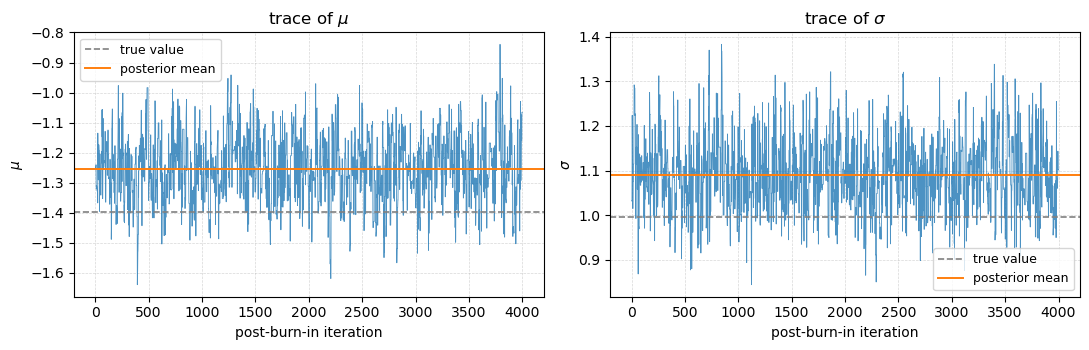

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
it_axis = np.arange(chain.shape[0])
for ax, j, name, truth in zip(
    axes, (0, 1), (r"$\mu$", r"$\sigma$"), (mu_true[0], sigma_true[0])
):
    ax.plot(it_axis, chain[:, j], color="tab:blue", linewidth=0.6, alpha=0.8)
    ax.axhline(truth, color="grey", linestyle="--", linewidth=1.2,
               label="true value")
    ax.axhline(chain[:, j].mean(), color="tab:orange", linewidth=1.4,
               label="posterior mean")
    ax.set_xlabel("post-burn-in iteration")
    ax.set_ylabel(name)
    ax.set_title(f"trace of {name}")
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

In [4]:
# Exercise the package API: run nbe.samplers.mh_normal on the same demo dataset
# and confirm its posterior mean agrees with the hand-rolled chain above.
api_rng = np.random.default_rng(22)
# Advance the RNG past the prior/data draws so the chain sees the same random
# stream as the hand-rolled version.
_ = sample_prior_normal(1, api_rng)
_ = simulate_normal(mu_true, sigma_true, N_OBS, api_rng)
mu_api, sigma_api = mh_normal(y_demo, N_ITER, BURN_IN, PROP_SCALE, api_rng)

print(f"hand-rolled chain  : mu = {mu_hat:.4f},  sigma = {sigma_hat:.4f}")
print(f"nbe.samplers.mh_normal: mu = {mu_api:.4f},  sigma = {sigma_api:.4f}")
print(f"difference         : |Δmu| = {abs(mu_hat - mu_api):.4f},  "
      f"|Δσ| = {abs(sigma_hat - sigma_api):.4f}")
# The two estimates agree to within normal Monte Carlo fluctuation,
# confirming that the package routine implements the same algorithm.

hand-rolled chain  : mu = -1.2532,  sigma = 1.0908
nbe.samplers.mh_normal: mu = -1.2532,  sigma = 1.0908
difference         : |Δmu| = 0.0000,  |Δσ| = 0.0000


## 2. The Gibbs sampler

Tuning the random-walk proposal $q$ to balance acceptance against exploration
is difficult, and grows harder as the dimension of $\boldsymbol{\theta}$
increases or its components differ in scale. For models with the right
conditional structure this tuning can be sidestepped entirely. Partition the
parameter vector into blocks $\boldsymbol{\theta} = (\boldsymbol{\theta}^{(1)},
\dots, \boldsymbol{\theta}^{(B)})$ and write $\boldsymbol{\theta}^{(-b)}$ for
all blocks but the $b$-th. The **full conditional** of block $b$ is
$p(\boldsymbol{\theta}^{(b)} \mid \boldsymbol{\theta}^{(-b)}, \mathbf{y})$. The
**Gibbs sampler** updates each block in turn by drawing it from its full
conditional, holding the others fixed.

The Gibbs sampler is a Metropolis–Hastings algorithm whose proposal for block
$b$ is the full conditional itself. Taking $q(\boldsymbol{\theta}^{(b)\prime}
\mid \boldsymbol{\theta}) = p(\boldsymbol{\theta}^{(b)\prime} \mid
\boldsymbol{\theta}^{(-b)}, \mathbf{y})$ in $(6)$ and factorising the joint
posterior as $p(\boldsymbol{\theta}^{(b)}, \boldsymbol{\theta}^{(-b)} \mid
\mathbf{y}) = p(\boldsymbol{\theta}^{(b)} \mid \boldsymbol{\theta}^{(-b)},
\mathbf{y})\, p(\boldsymbol{\theta}^{(-b)} \mid \mathbf{y})$,

$$
\begin{align}
  \alpha
  &= \min\!\left(1,\;
     \frac{p(\boldsymbol{\theta}^{(b)\prime} \mid \boldsymbol{\theta}^{(-b)},
            \mathbf{y})\,
           p(\boldsymbol{\theta}^{(-b)} \mid \mathbf{y})\,
           p(\boldsymbol{\theta}^{(b)} \mid \boldsymbol{\theta}^{(-b)},
            \mathbf{y})}
          {p(\boldsymbol{\theta}^{(b)} \mid \boldsymbol{\theta}^{(-b)},
            \mathbf{y})\,
           p(\boldsymbol{\theta}^{(-b)} \mid \mathbf{y})\,
           p(\boldsymbol{\theta}^{(b)\prime} \mid \boldsymbol{\theta}^{(-b)},
            \mathbf{y})}
     \right) \\
  &= 1,
  \tag{10}
\end{align}
$$

since every factor cancels. The Gibbs sampler is therefore a
Metropolis–Hastings algorithm with acceptance probability identically one: no
proposal is ever rejected, and the tuning problem disappears. The price is that
the full conditionals must be available in closed form and easy to sample —
most readily guaranteed when the model is **conditionally conjugate**.

**A conditionally conjugate example.** The normal model $(4)$ admits a clean
Gibbs sampler if we reparametrise the prior on the variance as conditionally
conjugate. With a flat (or inverse-Gamma) prior on $\sigma^2$ and the Gaussian
prior $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$, the two full conditionals are
standard. Conditioning on $\sigma^2$, the mean is Gaussian — completing the
square in $(8)$ in $\mu$ gives precision $\sigma_0^{-2} + n\sigma^{-2}$ and
mean a precision-weighted average of $\mu_0$ and $\bar y$,

$$
\begin{align}
  \mu \mid \sigma^2, \mathbf{y}
  \;\sim\; \mathcal{N}\!\left(
    \frac{\sigma_0^{-2}\mu_0 + n\sigma^{-2}\bar{y}}
         {\sigma_0^{-2} + n\sigma^{-2}},\;
    \big(\sigma_0^{-2} + n\sigma^{-2}\big)^{-1}
  \right).
  \tag{11}
\end{align}
$$

Conditioning instead on $\mu$, the variance has an inverse-Gamma full
conditional driven by the residual sum of squares $\sum_i (y_i - \mu)^2$,

$$
\begin{align}
  \sigma^2 \mid \mu, \mathbf{y}
  \;\sim\; \text{Inv-Gamma}\!\left(
    \tfrac{n}{2},\; \tfrac12\textstyle\sum_{i=1}^{n}(y_i - \mu)^2
  \right).
  \tag{12}
\end{align}
$$

Equations $(11)$–$(12)$ hold under the conjugate (flat or inverse-Gamma)
reparametrisation of the prior on $\sigma^2$; they do **not** apply directly
to the $\sigma \sim \mathcal{U}(0, A)$ prior of model $(4)$, which breaks
conjugacy. Metropolis–Hastings is the reference sampler of record precisely
because it needs no such reparametrisation — the uniform prior enters only
through the boundary condition $\sigma \notin (0, A) \Rightarrow \alpha = 0$
in $(9)$.

A Gibbs sweep alternates the draws $(11)$ and $(12)$, each accepted with
probability one by $(10)$. The same conditional structure underlies the
Bayesian linear-regression and AR(1) samplers used elsewhere in the thesis
(the package ships `nbe.samplers.gibbs_ar1` for the latter), and — as
Chapter 3 shows — it is exactly the structure that Rao–Blackwellisation
exploits. For the normal model studied here, Metropolis–Hastings is the
reference of record because it needs no reparametrisation of the $\sigma \sim
\mathcal{U}(0, A)$ prior; the Gibbs derivation above is included to show the
alternative and the role of conditional conjugacy.

## 3. Recovery and convergence across many datasets

A single chain is reassuring but anecdotal. The reference role these samplers
play in later chapters requires that posterior-mean recovery be reliable
*across the prior* — for every dataset a test set might contain. The next cell
therefore runs Metropolis–Hastings on `N_DATASETS` independent datasets, each
with its own $(\mu, \sigma)$ drawn from the prior $(4)$, and records two things:

1. **Recovery** — the posterior-mean estimate $(\hat\mu, \hat\sigma)$ against
   the data-generating $(\mu, \sigma)$, for the estimated-vs-true scatter.
2. **Convergence** — the running posterior mean as a function of chain length
   $N$, averaged over datasets, summarised as the mean absolute error
   $\frac1D\sum_d |\hat\theta_d(N) - \theta_d|$ at a grid of $N$. This shows the
   Monte Carlo error of $(3)$ shrinking as the chain lengthens.

The heavy loop is guarded by `if RUN_FULL:` and its results are cached to
`results/mcmc_normal_chains.npz`; the shipped notebook (`RUN_FULL = False`)
loads that cache.

In [5]:
from pathlib import Path

CACHE = Path("results/mcmc_normal_chains.npz")
N_DATASETS = 256
# Chain-length grid for the convergence diagnostic (post-burn-in counts).
N_GRID = np.array([50, 100, 250, 500, 1000, 2000, 4000])

if RUN_FULL:
    gen_rng = np.random.default_rng(0)
    mu_true_all, sigma_true_all = sample_prior_normal(N_DATASETS, gen_rng)
    Y = simulate_normal(mu_true_all, sigma_true_all, N_OBS, gen_rng)

    mu_hat_all = np.empty(N_DATASETS)
    sigma_hat_all = np.empty(N_DATASETS)
    # running-mean absolute error at each grid point, accumulated over datasets
    err_mu = np.zeros(N_GRID.size)
    err_sigma = np.zeros(N_GRID.size)

    for d in range(N_DATASETS):
        chain_rng = np.random.default_rng(1000 + d)
        draws, _ = mh_chain(Y[d], N_ITER, BURN_IN, PROP_SCALE, chain_rng)
        # final posterior mean (full retained chain) -> recovery scatter
        mu_hat_all[d], sigma_hat_all[d] = draws.mean(0)
        # running posterior mean truncated at each grid length -> convergence
        run_mu = np.cumsum(draws[:, 0]) / np.arange(1, draws.shape[0] + 1)
        run_sigma = np.cumsum(draws[:, 1]) / np.arange(1, draws.shape[0] + 1)
        idx = N_GRID - 1
        err_mu += np.abs(run_mu[idx] - mu_true_all[d])
        err_sigma += np.abs(run_sigma[idx] - sigma_true_all[d])

    err_mu /= N_DATASETS
    err_sigma /= N_DATASETS

    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        CACHE,
        mu_true=mu_true_all, sigma_true=sigma_true_all,
        mu_hat=mu_hat_all, sigma_hat=sigma_hat_all,
        n_grid=N_GRID, err_mu=err_mu, err_sigma=err_sigma,
    )
    print(f"computed and cached -> {CACHE}")
else:
    data = np.load(CACHE)
    mu_true_all, sigma_true_all = data["mu_true"], data["sigma_true"]
    mu_hat_all, sigma_hat_all = data["mu_hat"], data["sigma_hat"]
    N_GRID, err_mu, err_sigma = data["n_grid"], data["err_mu"], data["err_sigma"]
    print(f"loaded cache <- {CACHE}  ({mu_true_all.size} datasets)")

loaded cache <- results\mcmc_normal_chains.npz  (256 datasets)


**Recovery.** The scatter places each estimate against its truth; points
on the dashed $y = x$ line are exact. Both $\mu$ and $\sigma$ are recovered
tightly across the full prior range, confirming the sampler is a faithful
per-dataset reference.

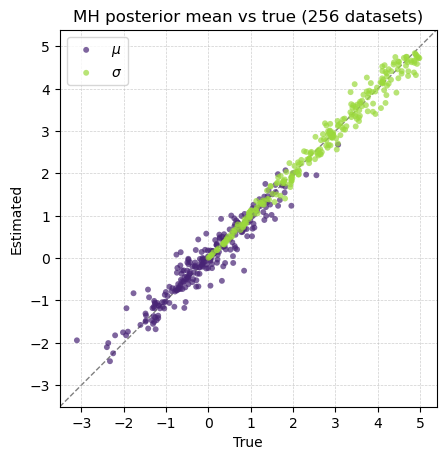

RMSE over datasets:  mu = 0.289,  sigma = 0.186


In [6]:
fig = est_vs_true(
    true=np.concatenate([mu_true_all, sigma_true_all]),
    est_dict={
        r"$\mu$": np.concatenate([mu_hat_all, np.full_like(sigma_hat_all, np.nan)]),
        r"$\sigma$": np.concatenate([np.full_like(mu_hat_all, np.nan), sigma_hat_all]),
    },
    names=[r"$\mu$", r"$\sigma$"],
)
fig.axes[0].set_title("MH posterior mean vs true (256 datasets)")
plt.show()

rmse_mu = np.sqrt(np.mean((mu_hat_all - mu_true_all) ** 2))
rmse_sigma = np.sqrt(np.mean((sigma_hat_all - sigma_true_all) ** 2))
print(f"RMSE over datasets:  mu = {rmse_mu:.3f},  sigma = {rmse_sigma:.3f}")

**Convergence.** Averaged over the 256 datasets, the mean absolute error
of the running posterior mean falls steadily as the chain lengthens — the
$O(N^{-1/2})$ decay of Monte Carlo error in $(3)$, slowed only by the
autocorrelation between successive MCMC draws. The curve flattens towards an
irreducible floor set by the finite data ($n = 100$ observations fix the
posterior width; no amount of sampling removes that), which is precisely the
posterior-mean recovery error seen in the scatter above.

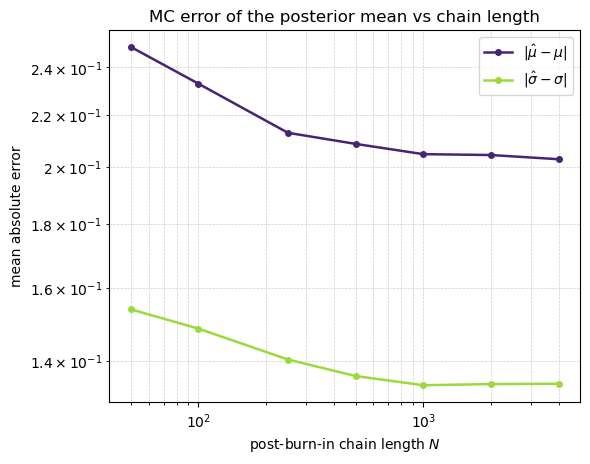

In [7]:
fig = convergence_curves(
    samples=N_GRID,
    curves_by_key={
        r"$|\hat\mu - \mu|$": err_mu,
        r"$|\hat\sigma - \sigma|$": err_sigma,
    },
)
fig.axes[0].set_xlabel("post-burn-in chain length $N$")
fig.axes[0].set_ylabel("mean absolute error")
fig.axes[0].set_title("MC error of the posterior mean vs chain length")
plt.show()

## 4. Beyond random walks: the Hamiltonian Monte Carlo idea

Random-walk Metropolis–Hastings proposals carry no information about the shape
of the posterior, and explore it by diffusion: the chain takes uncorrelated
steps and the distance covered grows only as the square root of the number of
iterations. In high dimensions, or when the posterior is strongly correlated,
this is slow. **Hamiltonian Monte Carlo (HMC)** replaces the blind random walk
with *gradient-informed* proposals.

The idea is to augment the parameter $\boldsymbol{\theta}$ with an auxiliary
**momentum** variable $\mathbf{r}$ and treat the pair as a physical system with
energy $H(\boldsymbol{\theta}, \mathbf{r}) = U(\boldsymbol{\theta}) +
K(\mathbf{r})$, where the *potential* $U(\boldsymbol{\theta}) = -\log
p(\boldsymbol{\theta} \mid \mathbf{y})$ is the negative log-posterior and the
*kinetic* term $K(\mathbf{r}) = \tfrac12 \mathbf{r}^{\top} M^{-1}\mathbf{r}$ is
a Gaussian quadratic form. A proposal is generated by drawing a random momentum
and then simulating Hamilton's equations — following the gradient
$\nabla_{\boldsymbol{\theta}} \log p(\boldsymbol{\theta} \mid \mathbf{y})$ — for
a fixed time, using the leapfrog integrator. Because the dynamics approximately
conserve $H$, the proposed state can be far from the current one yet still be
accepted with high probability, so the chain traverses the posterior in long,
informed strides rather than small random steps.

HMC and its self-tuning extension, the **No-U-Turn Sampler (NUTS)**, are the
default engines of modern probabilistic-programming systems such as Stan. They
are not used in this thesis — the normal, linear-regression and AR(1) models
are low-dimensional and either conditionally conjugate or cheap under a tuned
random walk — but they occupy the same niche: an *exact* per-dataset sampler
whose cost is paid afresh for every new dataset. That recurring cost is the
point of the next section.

## 5. Takeaway

- **Metropolis–Hastings** turns any proposal into a chain with the posterior as
  its stationary distribution, needing only the *unnormalised* posterior $(2)$
  because the evidence cancels from the acceptance ratio $(7)$. It is fully
  general, but its efficiency hinges on tuning the proposal $q$ — a problem that
  worsens with dimension and correlation. On the normal model a symmetric
  random walk recovers $(\mu, \sigma)$ accurately across the whole prior.
- **Gibbs sampling** sidesteps tuning altogether when the model is
  conditionally conjugate: each block is drawn from its full conditional and
  accepted with probability one $(10)$. The price is that those conditionals
  must be standard, samplable distributions — available for the linear-regression
  and AR(1) models, and the very structure Rao–Blackwellisation exploits in
  Chapter 3.
- **HMC / NUTS** improve mixing through gradient-informed proposals, the
  practical default for harder posteriors, but share the same structural
  property as the samplers above.

That shared property is the crux. Every sampler here targets the posterior of
**one** dataset: when a new dataset arrives, the whole procedure — warm-up,
tuning, thousands of iterations — is repeated from scratch, with no transferable
information between problems. For a handful of datasets this is fine; for the
hundreds or thousands of datasets a simulation study or an operational pipeline
demands, the cost scales linearly with no economy of scale. This is the
limitation that motivates **amortised** inference: invest computation once to
learn a reusable map from data to posterior summaries, after which each new
dataset costs a single forward pass. Building that map with neural networks —
and reducing the variance of its training signal — is the subject of the
chapters that follow.